# Control Systems Fundamentals: From Models to Feedback Design

This notebook builds control-system intuition from physical models to practical feedback design. It combines derivations, executable examples, and plots using **NumPy**, **SciPy**, **Matplotlib**, **SymPy**, and **python-control**.

## Learning objectives

By the end, you should be able to:

- derive transfer functions from differential equations;
- interpret natural frequency $\omega_n$ and damping ratio $\zeta$;
- predict stability, speed, and oscillation from poles and zeros;
- connect second-order dynamics to a physical series RLC circuit;
- evaluate transient response, steady-state error, and frequency-domain robustness;
- explain root locus, PID control, state space, controllability, observability, and sampled-data stability;
- follow a repeatable analysis and controller-design workflow.

> **Convention:** Continuous-time transfer functions use $s$. Unless stated otherwise, feedback is negative and unity feedback means $H(s)=1$.

## 1. Python Environment and Control Libraries

The first code cell imports the numerical, symbolic, plotting, and control libraries used throughout the notebook and prints their versions. Keeping this cell near the top makes the computational environment explicit and reproducible.

In [1]:
import sys

import control as ct
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sympy as sp
from scipy import linalg, signal

np.set_printoptions(precision=4, suppress=True)
mpl.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.28,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.0,
    "font.size": 11,
})
COLORS = plt.get_cmap("tab10").colors

print(f"Python       {sys.version.split()[0]}")
print(f"NumPy       {np.__version__}")
print(f"SciPy       {scipy.__version__}")
print(f"SymPy       {sp.__version__}")
print(f"Matplotlib  {mpl.__version__}")
print(f"control     {ct.__version__}")

Python       3.14.6
NumPy       2.5.2
SciPy       1.18.1
SymPy       1.14.0
Matplotlib  3.11.1
control     0.10.2


## 2. Modeling Dynamic Systems

A **dynamic system** stores energy or information, so its present output depends on past behavior. A model usually starts with conservation laws:

- Newton's law: $\sum F=m\ddot{x}$
- Kirchhoff's laws: $\sum v=0$ and $\sum i=0$
- conservation of mass, charge, momentum, or energy

Most introductory control methods assume a **linear time-invariant (LTI)** model. Linearity gives superposition; time invariance means the governing parameters do not change with time. Real plants are often approximated as LTI near an operating point.

### Mass-spring-damper example

For displacement $x(t)$, external force $F(t)$, mass $m$, viscous damping $b$, and stiffness $k$,

$$m\ddot{x}(t)+b\dot{x}(t)+kx(t)=F(t).$$

With zero initial conditions, the Laplace derivative rule $\mathcal{L}\{\dot{x}\}=sX(s)$ gives

$$(ms^2+bs+k)X(s)=F(s),$$

so the force-to-position transfer function is

$$G(s)=\frac{X(s)}{F(s)}=\frac{1}{ms^2+bs+k}.$$

The model is second order because its highest derivative is second order. The state of this mechanical system can be represented by position and velocity.

Laplace-domain equation:


Eq(X(s)*(b*s + k + m*s**2), F(s))

Force-to-position transfer function G(s) = X(s)/F(s):


1/(b*s + k + m*s**2)

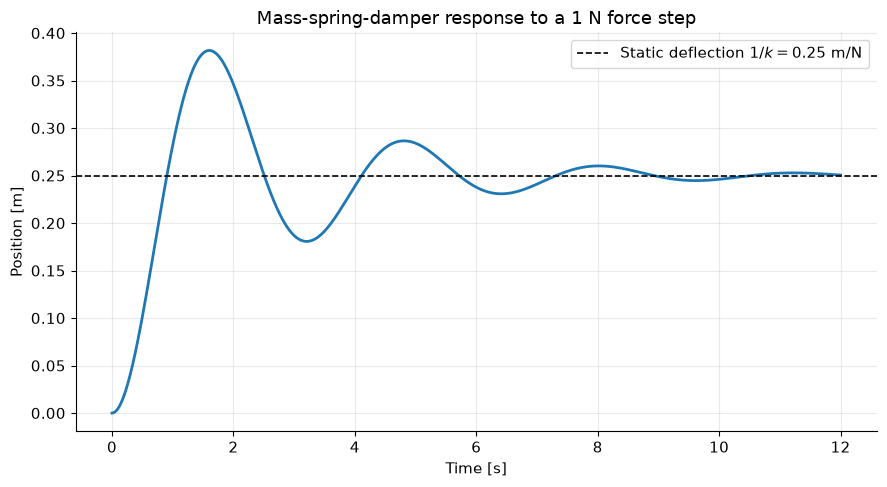

In [2]:
s = sp.symbols("s")
m_sym, b_sym, k_sym = sp.symbols("m b k", positive=True)
X_s, F_s = sp.symbols("X(s) F(s)")

laplace_equation = sp.Eq((m_sym * s**2 + b_sym * s + k_sym) * X_s, F_s)
G_symbolic = sp.simplify(sp.solve(laplace_equation, X_s)[0] / F_s)
print("Laplace-domain equation:")
display(laplace_equation)
print("Force-to-position transfer function G(s) = X(s)/F(s):")
display(G_symbolic)

m_value, b_value, k_value = 1.0, 0.8, 4.0
mass_spring_damper = ct.tf([1.0], [m_value, b_value, k_value])
time = np.linspace(0, 12, 1200)
time_out, position = ct.step_response(mass_spring_damper, T=time)

plt.plot(time_out, position, color=COLORS[0])
plt.axhline(1 / k_value, color="black", linestyle="--", linewidth=1.2,
            label=f"Static deflection $1/k={1/k_value:.2f}$ m/N")
plt.title("Mass-spring-damper response to a 1 N force step")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Transfer Functions and Block Diagrams

For an LTI system with zero initial conditions, the **transfer function** is

$$G(s)=\frac{Y(s)}{U(s)}=\frac{b_ms^m+\cdots+b_0}{a_ns^n+\cdots+a_0}.$$

Key vocabulary:

| Concept | Meaning |
|---|---|
| Order | Degree $n$ of the denominator after cancellations |
| Relative degree | $n-m$ |
| Proper / strictly proper | $n\ge m$ / $n>m$ |
| Poles | Roots of the denominator |
| Zeros | Roots of the numerator |
| DC gain | $G(0)$ when finite |

Ideal block-diagram algebra is simple:

- series: $G_{series}=G_1G_2$
- parallel: $G_{parallel}=G_1+G_2$
- negative feedback: $G_{cl}=G/(1+GH)$

For a forward path $G$ and feedback path $H$,

$$Y=G(R-HY)\quad\Longrightarrow\quad \frac{Y}{R}=\frac{G}{1+GH}.$$

The equation $1+G(s)H(s)=0$ is the **closed-loop characteristic equation**. Its roots are the closed-loop poles and therefore govern closed-loop stability and natural response.

G1(s) = <TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    1
  -----
  s + 1
Series G1 G2 = <TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        2
  -------------
  s^2 + 4 s + 3
Parallel G1 + G2 = <TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     3 s + 5
  -------------
  s^2 + 4 s + 3
Unity-feedback G1 G2 / (1 + G1 G2) = <TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        2
  -------------
  s^2 + 4 s + 5
Closed-loop poles: [-2.+1.j -2.-1.j]


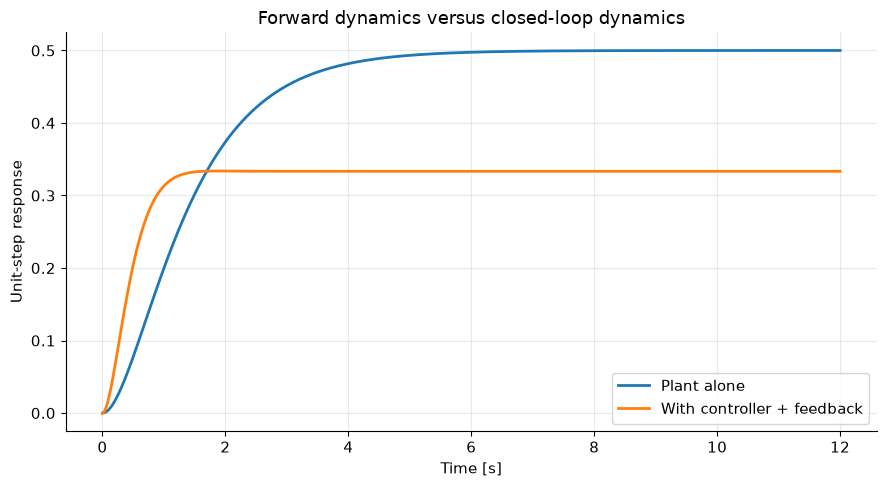

In [3]:
s_tf = ct.tf("s")
G1 = 1 / (s_tf + 1)
G2 = 2 / (s_tf + 3)
series_connection = ct.series(G1, G2)
parallel_connection = ct.parallel(G1, G2)
feedback_connection = ct.feedback(G1 * G2, 1)

print("G1(s) =", G1)
print("Series G1 G2 =", series_connection)
print("Parallel G1 + G2 =", parallel_connection)
print("Unity-feedback G1 G2 / (1 + G1 G2) =", feedback_connection)
print("Closed-loop poles:", ct.poles(feedback_connection))

plant_example = 1 / (s_tf**2 + 3 * s_tf + 2)
controller_example = 5 * (s_tf + 1) / (s_tf + 5)
closed_loop_example = ct.feedback(controller_example * plant_example, 1)
time = np.linspace(0, 12, 1200)

plt.plot(*ct.step_response(plant_example, T=time), label="Plant alone")
plt.plot(*ct.step_response(closed_loop_example, T=time), label="With controller + feedback")
plt.title("Forward dynamics versus closed-loop dynamics")
plt.xlabel("Time [s]")
plt.ylabel("Unit-step response")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Deriving the Standard Second-Order System

Start from a general second-order differential equation with positive leading coefficient:

$$a_2\ddot{y}+a_1\dot{y}+a_0y=b_0u.$$

After a zero-initial-condition Laplace transform,

$$\frac{Y(s)}{U(s)}=\frac{b_0}{a_2s^2+a_1s+a_0}
=\frac{b_0/a_2}{s^2+(a_1/a_2)s+a_0/a_2}.$$

Compare its denominator with the canonical form

$$s^2+2\zeta\omega_n s+\omega_n^2.$$

Matching coefficients gives

$$\boxed{\omega_n=\sqrt{\frac{a_0}{a_2}}},\qquad
\boxed{\zeta=\frac{a_1}{2\sqrt{a_0a_2}}}.$$

For unity DC gain, the canonical transfer function is

$$G(s)=\frac{\omega_n^2}{s^2+2\zeta\omega_ns+\omega_n^2}.$$

For the mass-spring-damper system, $a_2=m$, $a_1=b$, and $a_0=k$, so

$$\omega_n=\sqrt{\frac{k}{m}},\qquad \zeta=\frac{b}{2\sqrt{km}}.$$

The units cancel in $\zeta$, so damping ratio is dimensionless.

## 5. Damping Ratio and Natural Frequency

Solving the characteristic equation gives

$$s_{1,2}=-\zeta\omega_n\pm\omega_n\sqrt{\zeta^2-1}.$$

For $0<\zeta<1$, write the poles as

$$s_{1,2}=-\zeta\omega_n\pm j\omega_d,
\qquad \omega_d=\omega_n\sqrt{1-\zeta^2}.$$

| Damping ratio | Classification | Expected natural response |
|---:|---|---|
| $\zeta<0$ | Negative damping, unstable | Growing oscillation or exponentials |
| $\zeta=0$ | Undamped, marginal idealization | Sustained oscillation |
| $0<\zeta<1$ | Underdamped | Decaying oscillation and possible overshoot |
| $\zeta=1$ | Critically damped | Fastest nonoscillatory canonical response |
| $\zeta>1$ | Overdamped | Two decaying real modes; larger $\zeta$ can be slower |

$\omega_n$ sets the overall time scale, while $\zeta$ sets the response shape. Both are needed to predict speed.

In [4]:
a2, a1, a0, omega_n_sym, zeta_sym = sp.symbols(
    "a_2 a_1 a_0 omega_n zeta", positive=True
)
coefficient_solution = sp.solve(
    [sp.Eq(2 * zeta_sym * omega_n_sym, a1 / a2),
     sp.Eq(omega_n_sym**2, a0 / a2)],
    [omega_n_sym, zeta_sym],
    dict=True,
)[0]
print("Coefficient matching gives:")
display(coefficient_solution)


def second_order_system(zeta, omega_n=4.0):
    """Canonical unity-DC-gain second-order transfer function."""
    return ct.tf([omega_n**2], [1.0, 2.0 * zeta * omega_n, omega_n**2])


def damping_class(zeta):
    if zeta < 0:
        return "unstable (negative damping)"
    if np.isclose(zeta, 0):
        return "undamped"
    if zeta < 1:
        return "underdamped"
    if np.isclose(zeta, 1):
        return "critically damped"
    return "overdamped"


omega_n_value = 4.0
zeta_values = [-0.1, 0.0, 0.2, 0.5, 0.707, 1.0, 1.5, 2.0]
print(f"\nPoles for omega_n = {omega_n_value:g} rad/s")
print(f"{'zeta':>7}  {'classification':>29}  poles")
for zeta in zeta_values:
    poles = np.roots([1.0, 2 * zeta * omega_n_value, omega_n_value**2])
    print(f"{zeta:7.3f}  {damping_class(zeta):>29}  {np.array2string(poles, precision=3)}")

Coefficient matching gives:


{omega_n: sqrt(a_0)/sqrt(a_2), zeta: a_1/(2*sqrt(a_0)*sqrt(a_2))}


Poles for omega_n = 4 rad/s
   zeta                 classification  poles
 -0.100    unstable (negative damping)  [0.4+3.98j 0.4-3.98j]
  0.000                       undamped  [-0.+4.j  0.-4.j]
  0.200                    underdamped  [-0.8+3.919j -0.8-3.919j]
  0.500                    underdamped  [-2.+3.464j -2.-3.464j]
  0.707                    underdamped  [-2.828+2.829j -2.828-2.829j]
  1.000              critically damped  [-4. -4.]
  1.500                     overdamped  [-10.472  -1.528]
  2.000                     overdamped  [-14.928  -1.072]


## 6. Visualizing Different Damping Ratios

The next experiment holds $\omega_n=4\ \mathrm{rad/s}$ fixed and varies only $\zeta$. This isolates damping-ratio effects:

- small positive $\zeta$: quick initial motion but substantial ringing;
- $\zeta\approx0.7$: common compromise between speed and overshoot;
- $\zeta=1$: no overshoot and no repeated pole oscillation;
- large $\zeta$: no oscillation, but a slow dominant real pole;
- $\zeta\le0$: no asymptotic settling.

The unstable case is placed on a separate axis because its growing amplitude would compress the stable curves.

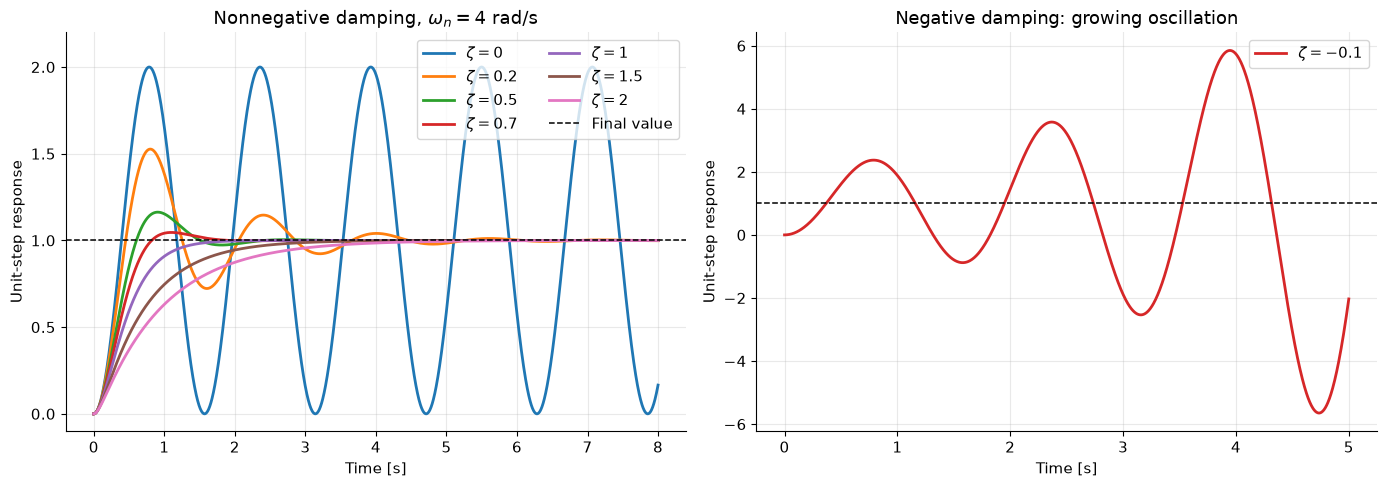

In [5]:
time_stable = np.linspace(0, 8, 2000)
time_unstable = np.linspace(0, 5, 1400)
stable_zetas = [0.0, 0.2, 0.5, 0.7, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for index, zeta in enumerate(stable_zetas):
    response_time, response = ct.step_response(
        second_order_system(zeta, omega_n_value), T=time_stable
    )
    axes[0].plot(response_time, response, color=COLORS[index], label=fr"$\zeta={zeta:g}$")

axes[0].axhline(1, color="black", linestyle="--", linewidth=1.1, label="Final value")
axes[0].set_title(fr"Nonnegative damping, $\omega_n={omega_n_value:g}$ rad/s")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Unit-step response")
axes[0].set_ylim(-0.1, 2.2)
axes[0].legend(ncols=2)

unstable_zeta = -0.1
unstable_time, unstable_response = ct.step_response(
    second_order_system(unstable_zeta, omega_n_value), T=time_unstable
)
axes[1].plot(unstable_time, unstable_response, color=COLORS[3],
             label=fr"$\zeta={unstable_zeta:g}$")
axes[1].axhline(1, color="black", linestyle="--", linewidth=1.1)
axes[1].set_title("Negative damping: growing oscillation")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend()

fig.tight_layout()
plt.show()

## 7. Transient-Response Performance Metrics

For the canonical underdamped system with $0<\zeta<1$:

$$\omega_d=\omega_n\sqrt{1-\zeta^2},$$

$$t_p=\frac{\pi}{\omega_d},$$

$$M_p=100\exp\!\left(\frac{-\pi\zeta}{\sqrt{1-\zeta^2}}\right)\%,$$

$$t_s\approx\frac{4}{\zeta\omega_n}\quad\text{for a 2\% band},$$

and the first 0-to-100% crossing is

$$t_r=\frac{\pi-\cos^{-1}(\zeta)}{\omega_d}.$$

Common specifications:

- **rise time:** often 10% to 90%, though conventions vary;
- **peak time:** time of the first maximum;
- **percent overshoot:** peak excursion above the final value;
- **settling time:** first time after which the output remains inside a tolerance band.

These formulas assume a stable, zero-free, canonical second-order system. Additional poles, zeros, delays, saturation, and non-unity final values can make them inaccurate. The code below measures the simulated curve and compares it with the analytical formulas.

In [6]:
def measured_step_metrics(time_values, response_values, final_value=1.0, tolerance=0.02):
    """Measure first 100% crossing, first peak, overshoot, and settling time."""
    crossing_indices = np.flatnonzero(response_values >= final_value)
    rise_time_0_100 = time_values[crossing_indices[0]] if crossing_indices.size else np.nan

    peak_index = int(np.argmax(response_values))
    peak_time = time_values[peak_index]
    overshoot = max(0.0, 100 * (response_values[peak_index] - final_value) / abs(final_value))

    outside = np.flatnonzero(np.abs(response_values - final_value) > tolerance * abs(final_value))
    if outside.size == 0:
        settling_time = 0.0
    elif outside[-1] + 1 < time_values.size:
        settling_time = time_values[outside[-1] + 1]
    else:
        settling_time = np.nan
    return rise_time_0_100, peak_time, overshoot, settling_time


metric_time = np.linspace(0, 15, 20000)
print("Analytical formulas versus measurements from the sampled response")
print(" zeta | tr formula  tr sim | tp formula  tp sim | OS formula  OS sim | Ts approx  Ts sim")
print("-------+--------------------+--------------------+--------------------+-----------------")
for zeta in [0.2, 0.5, 0.7]:
    omega_d = omega_n_value * np.sqrt(1 - zeta**2)
    rise_formula = (np.pi - np.arccos(zeta)) / omega_d
    peak_formula = np.pi / omega_d
    overshoot_formula = 100 * np.exp(-np.pi * zeta / np.sqrt(1 - zeta**2))
    settling_formula = 4 / (zeta * omega_n_value)

    response_time, response = ct.step_response(
        second_order_system(zeta, omega_n_value), T=metric_time
    )
    rise_sim, peak_sim, overshoot_sim, settling_sim = measured_step_metrics(
        response_time, response
    )
    print(
        f" {zeta:5.2f} | {rise_formula:9.3f} {rise_sim:7.3f} |"
        f" {peak_formula:10.3f} {peak_sim:7.3f} |"
        f" {overshoot_formula:10.2f} {overshoot_sim:7.2f} |"
        f" {settling_formula:9.3f} {settling_sim:7.3f}"
    )

Analytical formulas versus measurements from the sampled response
 zeta | tr formula  tr sim | tp formula  tp sim | OS formula  OS sim | Ts approx  Ts sim
-------+--------------------+--------------------+--------------------+-----------------
  0.20 |     0.452   0.452 |      0.802   0.802 |      52.66   52.66 |     5.000   4.901
  0.50 |     0.605   0.605 |      0.907   0.907 |      16.30   16.30 |     2.000   2.019
  0.70 |     0.821   0.822 |      1.100   1.100 |       4.60    4.60 |     1.429   1.495


## 8. Modeling a Series RLC Circuit

Consider a series resistor $R$, inductor $L$, and capacitor $C$, with input voltage $v_{in}$ across the series branch and output $v_C$ across the capacitor.

Kirchhoff's voltage law gives

$$v_{in}=v_R+v_L+v_C=Ri+L\frac{di}{dt}+v_C.$$

Because the series current is the capacitor current,

$$i=C\frac{dv_C}{dt}.$$

Substitution produces

$$LC\frac{d^2v_C}{dt^2}+RC\frac{dv_C}{dt}+v_C=v_{in}.$$

Therefore,

$$H_C(s)=\frac{V_C(s)}{V_{in}(s)}
=\frac{1}{LCs^2+RCs+1}
=\frac{1/(LC)}{s^2+(R/L)s+1/(LC)}.$$

Matching the standard second-order denominator gives

$$\boxed{\omega_n=\frac{1}{\sqrt{LC}}},\qquad
\boxed{\zeta=\frac{R}{2}\sqrt{\frac{C}{L}}}.$$

Useful equivalent relations are

$$\boxed{R_{crit}=2\sqrt{\frac{L}{C}}},\qquad
Q=\frac{1}{2\zeta}=\frac{1}{R}\sqrt{\frac{L}{C}}.$$

The inductor and capacitor exchange magnetic and electric energy. Resistance dissipates that energy, increasing damping. The denominator, and thus the poles, is common to all voltages and currents in this series circuit, but different measured outputs can introduce different zeros.

In [7]:
R_sym, L_sym, C_sym = sp.symbols("R L C", positive=True)
rlc_solution = sp.solve(
    [sp.Eq(2 * zeta_sym * omega_n_sym, R_sym / L_sym),
     sp.Eq(omega_n_sym**2, 1 / (L_sym * C_sym))],
    [omega_n_sym, zeta_sym],
    dict=True,
)[0]
print("RLC coefficient matching gives:")
display(rlc_solution)

L_value = 10e-3       # H
C_value = 100e-6      # F
omega_n_rlc = 1 / np.sqrt(L_value * C_value)
critical_resistance = 2 * np.sqrt(L_value / C_value)
print(f"For L = {L_value * 1e3:g} mH and C = {C_value * 1e6:g} uF:")
print(f"  natural frequency = {omega_n_rlc:.1f} rad/s ({omega_n_rlc / (2*np.pi):.1f} Hz)")
print(f"  critical resistance = {critical_resistance:.2f} ohm")

RLC coefficient matching gives:


{omega_n: 1/(sqrt(C)*sqrt(L)), zeta: sqrt(C)*R/(2*sqrt(L))}

For L = 10 mH and C = 100 uF:
  natural frequency = 1000.0 rad/s (159.2 Hz)
  critical resistance = 20.00 ohm


## 9. Effect of Damping on the RLC Circuit

Holding $L$ and $C$ fixed also holds $\omega_n$ fixed. Varying $R$ therefore makes a clean physical damping experiment:

$$R=2\zeta\sqrt{\frac{L}{C}}.$$

A value $\zeta=1/\sqrt{2}\approx0.707$ is the second-order Butterworth condition (maximally flat low-frequency magnitude), not the same as critical damping. Critical damping occurs at $\zeta=1$.

 target zeta | R [ohm] |    Q    | poles [rad/s]
-------------+---------+---------+--------------------------------
       0.200 |    4.00 |   2.500 | [-200.+979.8j -200.-979.8j]
       0.500 |   10.00 |   1.000 | [-500.+866.j -500.-866.j]
       0.707 |   14.14 |   0.707 | [-707.1+707.1j -707.1-707.1j]
       1.000 |   20.00 |   0.500 | [-1000.+0.j -1000.-0.j]
       2.000 |   40.00 |   0.250 | [-3732.1+0.j  -267.9+0.j]


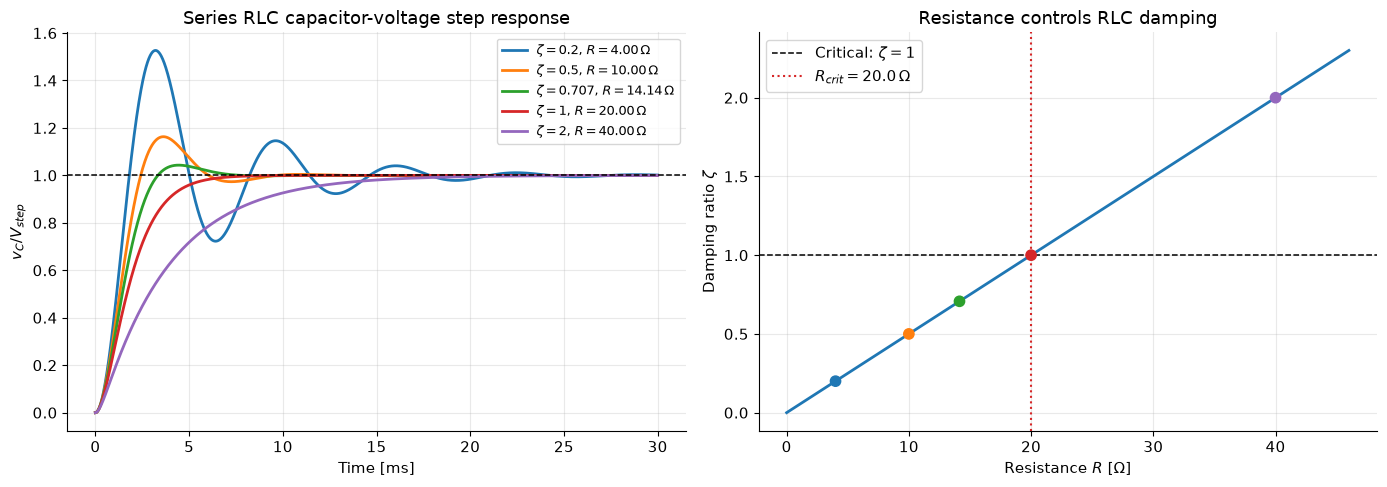

In [8]:
target_zetas = np.array([0.2, 0.5, 1 / np.sqrt(2), 1.0, 2.0])
resistances = 2 * target_zetas * np.sqrt(L_value / C_value)
rlc_time = np.linspace(0, 0.03, 3000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
print(" target zeta | R [ohm] |    Q    | poles [rad/s]")
print("-------------+---------+---------+--------------------------------")
for index, (zeta, resistance) in enumerate(zip(target_zetas, resistances)):
    capacitor_tf = ct.tf(
        [1.0],
        [L_value * C_value, resistance * C_value, 1.0],
    )
    response_time, capacitor_voltage = ct.step_response(capacitor_tf, T=rlc_time)
    axes[0].plot(
        1e3 * response_time,
        capacitor_voltage,
        color=COLORS[index],
        label=fr"$\zeta={zeta:.3g}$, $R={resistance:.2f}\,\Omega$",
    )
    quality_factor = 1 / (2 * zeta)
    print(
        f" {zeta:11.3f} | {resistance:7.2f} | {quality_factor:7.3f} | "
        f"{np.array2string(ct.poles(capacitor_tf), precision=1)}"
    )

axes[0].axhline(1, color="black", linestyle="--", linewidth=1.1)
axes[0].set_title("Series RLC capacitor-voltage step response")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel(r"$v_C / V_{step}$")
axes[0].legend(fontsize=9)

resistance_axis = np.linspace(0, 1.15 * resistances.max(), 400)
zeta_axis = (resistance_axis / 2) * np.sqrt(C_value / L_value)
axes[1].plot(resistance_axis, zeta_axis, color=COLORS[0])
axes[1].scatter(resistances, target_zetas, c=COLORS[:len(target_zetas)], s=55, zorder=3)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1.1, label=r"Critical: $\zeta=1$")
axes[1].axvline(critical_resistance, color=COLORS[3], linestyle=":", linewidth=1.5,
                label=fr"$R_{{crit}}={critical_resistance:.1f}\,\Omega$")
axes[1].set_title("Resistance controls RLC damping")
axes[1].set_xlabel(r"Resistance $R$ [$\Omega$]")
axes[1].set_ylabel(r"Damping ratio $\zeta$")
axes[1].legend()

fig.tight_layout()
plt.show()

## 10. Poles, Zeros, and the Complex Plane

A rational transfer function can be factored as

$$G(s)=K\frac{\prod_i(s-z_i)}{\prod_k(s-p_k)},$$

where $z_i$ are **zeros** and $p_k$ are **poles**. Repeated roots have multiplicity greater than one.

A mode associated with a pole $p=\sigma+j\omega$ behaves like

$$e^{pt}=e^{\sigma t}(\cos\omega t+j\sin\omega t).$$

Therefore:

- $\sigma<0$: the mode decays, with envelope time constant approximately $1/|\sigma|$;
- $\sigma>0$: the mode grows;
- $|\omega|$: oscillation frequency in rad/s;
- poles nearest the imaginary axis are often **dominant** because they decay slowest.

For an underdamped second-order pair,

$$\omega_n=|p|,\qquad \zeta=-\frac{\operatorname{Re}(p)}{|p|}.$$

Thus constant $\omega_n$ forms a circle and constant $\zeta$ forms rays in the left half-plane. This circle relation applies directly to the complex pair; overdamped real roots have unequal magnitudes.

Zeros do not create autonomous modes, but they weight and reshape the modes visible between a chosen input and output. Their location can strongly affect rise, overshoot, phase, and even the initial direction of motion.

Example system poles: [-4.+0.j     -1.+2.8284j -1.-2.8284j]
Example system zeros: [-1.+0.j]


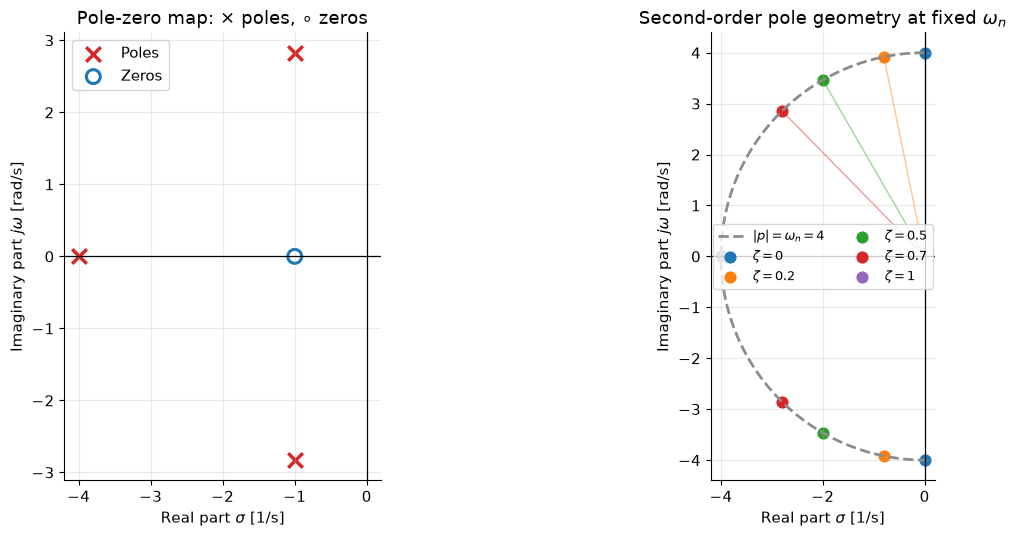

In [10]:
example_pz_system = 12 * (s_tf + 1) / ((s_tf + 4) * (s_tf**2 + 2 * s_tf + 9))
example_poles = ct.poles(example_pz_system)
example_zeros = ct.zeros(example_pz_system)
print("Example system poles:", example_poles)
print("Example system zeros:", example_zeros)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(example_poles.real, example_poles.imag, marker="x", s=110,
                linewidths=2.5, color=COLORS[3], label="Poles")
axes[0].scatter(example_zeros.real, example_zeros.imag, marker="o", s=100,
                facecolors="none", edgecolors=COLORS[0], linewidths=2.2, label="Zeros")
axes[0].axhline(0, color="black", linewidth=0.9)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title(r"Pole-zero map: $\times$ poles, $\circ$ zeros")
axes[0].set_xlabel(r"Real part $\sigma$ [1/s]")
axes[0].set_ylabel(r"Imaginary part $j\omega$ [rad/s]")
axes[0].legend()

geometry_zetas = [0.0, 0.2, 0.5, 0.7, 1.0]
angle = np.linspace(np.pi / 2, 3 * np.pi / 2, 300)
axes[1].plot(omega_n_value * np.cos(angle), omega_n_value * np.sin(angle),
             color="0.55", linestyle="--", label=fr"$|p|=\omega_n={omega_n_value:g}$")
for index, zeta in enumerate(geometry_zetas):
    poles = np.roots([1, 2 * zeta * omega_n_value, omega_n_value**2])
    axes[1].scatter(poles.real, poles.imag, color=COLORS[index], s=60,
                    label=fr"$\zeta={zeta:g}$")
    if zeta < 1:
        axes[1].plot([0, poles[0].real], [0, poles[0].imag],
                     color=COLORS[index], alpha=0.45, linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.9)
axes[1].axvline(0, color="black", linewidth=0.9)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title(r"Second-order pole geometry at fixed $\omega_n$")
axes[1].set_xlabel(r"Real part $\sigma$ [1/s]")
axes[1].set_ylabel(r"Imaginary part $j\omega$ [rad/s]")
axes[1].legend(fontsize=9, ncols=2)

fig.tight_layout()
plt.show()

## 11. Poles and System Stability

For a proper, minimal, continuous-time rational transfer function:

- **BIBO stable:** every pole lies strictly in the open left half-plane (LHP);
- **unstable:** at least one pole lies in the right half-plane (RHP), or a repeated pole lies on the imaginary axis;
- **marginal natural response:** simple imaginary-axis poles with all other poles in the LHP can produce bounded, nondecaying oscillation, but this is not asymptotic stability and generally is not BIBO stability.

**Internal stability** is stronger than stability of one displayed transfer function. An exact unstable pole-zero cancellation may hide an unstable internal mode; physical parameter error makes such cancellations especially unsafe.

### Characteristic equation and Routh-Hurwitz idea

Closed-loop stability is determined by the characteristic polynomial. For

$$a_3s^3+a_2s^2+a_1s+a_0,$$

the first Routh-column entries are

$$a_3,\quad a_2,\quad \frac{a_2a_1-a_3a_0}{a_2},\quad a_0.$$

With $a_3>0$, all must be positive for strict LHP stability. In particular, positive coefficients alone are not enough; the cubic also needs $a_2a_1>a_3a_0$. Routh-Hurwitz counts RHP roots without explicitly solving for them.

Stable: poles at -1 +/- j1.73
  asymptotically stable; poles = [-1.+1.7321j -1.-1.7321j]
Imaginary-axis pair: poles at +/- j2
  boundary poles: inspect multiplicity/BIBO behavior; poles = [-0.+2.j  0.-2.j]
Unstable: poles at 0.2 +/- j1.99
  unstable; poles = [0.2+1.99j 0.2-1.99j]


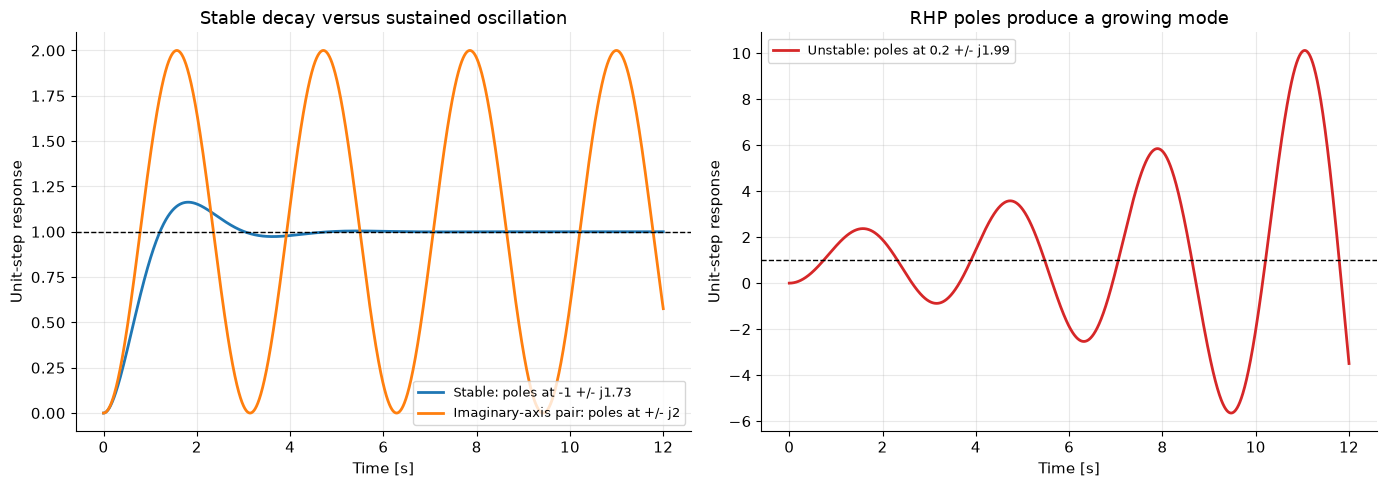

In [11]:
def pole_location_class(system, tolerance=1e-9):
    real_parts = ct.poles(system).real
    if np.any(real_parts > tolerance):
        return "unstable"
    if np.all(real_parts < -tolerance):
        return "asymptotically stable"
    return "boundary poles: inspect multiplicity/BIBO behavior"


stability_systems = {
    "Stable: poles at -1 +/- j1.73": ct.tf([4], [1, 2, 4]),
    "Imaginary-axis pair: poles at +/- j2": ct.tf([4], [1, 0, 4]),
    "Unstable: poles at 0.2 +/- j1.99": ct.tf([4], [1, -0.4, 4]),
}
for name, system in stability_systems.items():
    print(f"{name}\n  {pole_location_class(system)}; poles = {ct.poles(system)}")

stable_time = np.linspace(0, 12, 2200)
unstable_time = np.linspace(0, 12, 2200)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for index, name in enumerate(list(stability_systems)[:2]):
    response_time, response = ct.step_response(stability_systems[name], T=stable_time)
    axes[0].plot(response_time, response, color=COLORS[index], label=name)
axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Stable decay versus sustained oscillation")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Unit-step response")
axes[0].legend(fontsize=9)

unstable_name = list(stability_systems)[2]
response_time, response = ct.step_response(stability_systems[unstable_name], T=unstable_time)
axes[1].plot(response_time, response, color=COLORS[3], label=unstable_name)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("RHP poles produce a growing mode")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## 12. Pole Locations and Response Speed

For a dominant pole $p=\sigma+j\omega$:

- the envelope is $e^{\sigma t}$, so more-negative $\sigma$ means faster decay;
- $|\omega|$ sets oscillation frequency;
- a common 2% settling estimate for a dominant mode is $t_s\approx4/|\sigma|$.

A pole farther left is usually faster **when comparing similar, stable systems without problematic zeros, delays, hidden slow modes, or actuator limits**. In a high-order model, the stable poles closest to the imaginary axis tend to dominate late-time behavior. A dominant-pole approximation is most credible when neglected poles are several times farther left and are not amplified by zeros or residues.

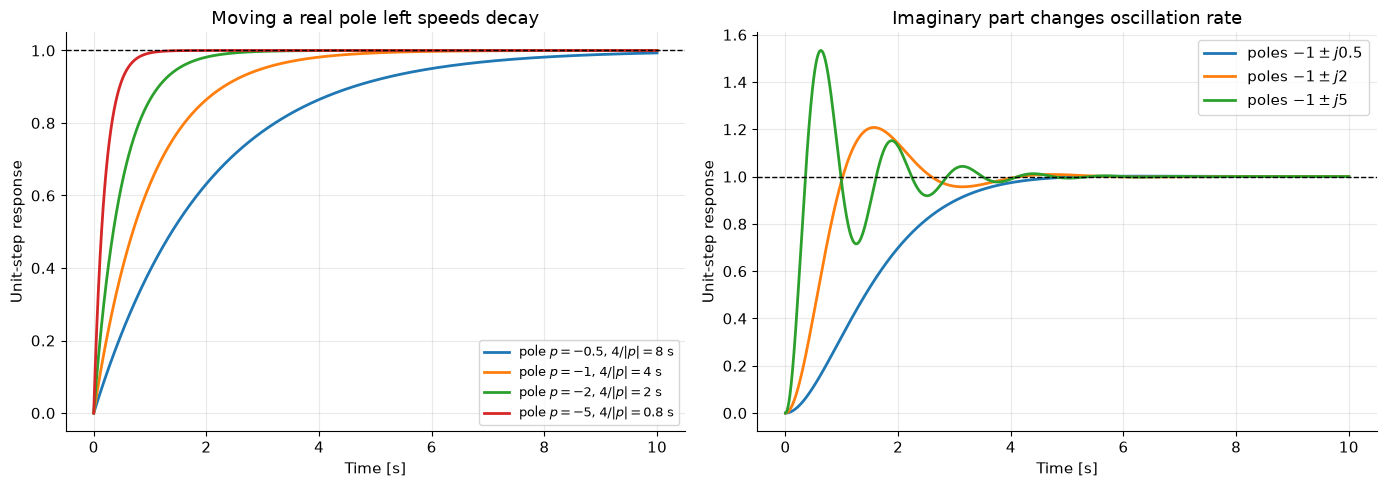

In [12]:
speed_time = np.linspace(0, 10, 1800)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pole_rates = [0.5, 1.0, 2.0, 5.0]
for index, rate in enumerate(pole_rates):
    first_order = rate / (s_tf + rate)
    response_time, response = ct.step_response(first_order, T=speed_time)
    axes[0].plot(response_time, response, color=COLORS[index],
                 label=fr"pole $p={-rate:g}$, $4/|p|={4/rate:g}$ s")
axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Moving a real pole left speeds decay")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Unit-step response")
axes[0].legend(fontsize=9)

fixed_sigma = -1.0
imaginary_parts = [0.5, 2.0, 5.0]
for index, omega in enumerate(imaginary_parts):
    denominator = [1.0, -2 * fixed_sigma, fixed_sigma**2 + omega**2]
    oscillatory_system = ct.tf([fixed_sigma**2 + omega**2], denominator)
    response_time, response = ct.step_response(oscillatory_system, T=speed_time)
    axes[1].plot(response_time, response, color=COLORS[index],
                 label=fr"poles $-1\pm j{omega:g}$")
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Imaginary part changes oscillation rate")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend()

fig.tight_layout()
plt.show()

## 13. Zeros and Their Effect on Response

Zeros shape how pole modes combine in a particular input-output channel.

- An LHP zero is **minimum phase** and often adds phase lead and a faster-looking initial response.
- An RHP zero is **nonminimum phase**. It contributes extra phase lag and commonly produces an inverse response: the output initially moves opposite its final direction.
- A zero close to a pole can reduce that mode's visible residue, but exact cancellation is fragile.
- Zeros do not determine BIBO stability; poles do. However, an unstable pole canceled in one transfer function can remain as a dangerous hidden internal mode.

A RHP zero and its mirrored LHP zero have the same frequency-response magnitude factor on $s=j\omega$, but different phase. This imposes a fundamental speed-versus-robustness limitation on nonminimum-phase plants.

The following systems have the **same poles and the same DC gain**. Only their zeros differ, so the transient differences come from numerator dynamics.

No finite zero    : DC gain=1.00, zeros=[], poles=[-4.+0.j -2.+0.j]
LHP zero at -1    : DC gain=1.00, zeros=[-1.+0.j], poles=[-4.+0.j -2.+0.j]
RHP zero at +1    : DC gain=1.00, zeros=[1.+0.j], poles=[-4.+0.j -2.+0.j]


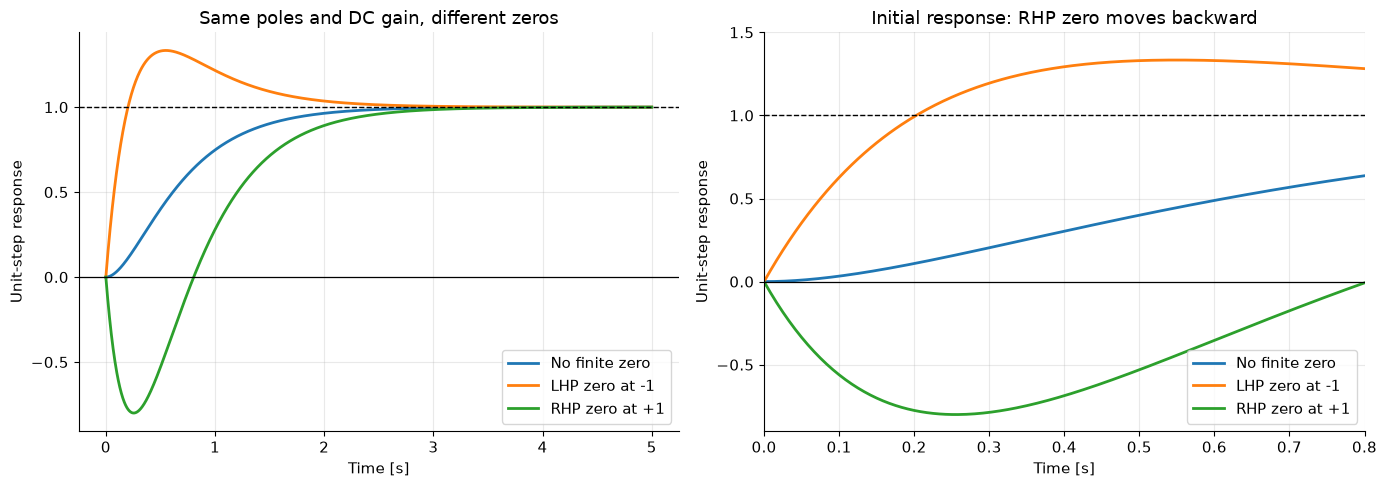

In [13]:
common_denominator = (s_tf + 2) * (s_tf + 4)
zero_comparison = {
    "No finite zero": 8 / common_denominator,
    "LHP zero at -1": 8 * (s_tf + 1) / common_denominator,
    "RHP zero at +1": 8 * (1 - s_tf) / common_denominator,
}
zero_time = np.linspace(0, 5, 1800)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for index, (label, system) in enumerate(zero_comparison.items()):
    response_time, response = ct.step_response(system, T=zero_time)
    print(
        f"{label:18s}: DC gain={ct.dcgain(system):.2f}, "
        f"zeros={ct.zeros(system)}, poles={ct.poles(system)}"
    )
    for axis in axes:
        axis.plot(response_time, response, color=COLORS[index], label=label)

for axis in axes:
    axis.axhline(0, color="black", linewidth=0.9)
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set_xlabel("Time [s]")
    axis.set_ylabel("Unit-step response")
axes[0].set_title("Same poles and DC gain, different zeros")
axes[0].legend()
axes[1].set_xlim(0, 0.8)
axes[1].set_ylim(-0.9, 1.5)
axes[1].set_title("Initial response: RHP zero moves backward")
axes[1].legend()

fig.tight_layout()
plt.show()

## 14. Steady-State Error and System Type

For unity negative feedback with loop transfer $L(s)=C(s)G(s)$,

$$E(s)=\frac{R(s)}{1+L(s)}.$$

If the relevant closed-loop signals are stable and the final-value theorem applies,

$$e_{ss}=\lim_{t\to\infty}e(t)=\lim_{s\to0}sE(s).$$

Define the low-frequency error constants

$$K_p=\lim_{s\to0}L(s),\qquad
K_v=\lim_{s\to0}sL(s),\qquad
K_a=\lim_{s\to0}s^2L(s).$$

For unit step, ramp, and parabolic commands $1$, $t$, and $t^2/2$:

$$e_{step}=\frac{1}{1+K_p},\qquad
e_{ramp}=\frac{1}{K_v},\qquad
e_{parabolic}=\frac{1}{K_a}.$$

The **system type** is the number of uncanceled poles at the origin in $L(s)$.

| Type | Step error | Ramp error | Parabolic error |
|---:|---:|---:|---:|
| 0 | finite | infinite | infinite |
| 1 | zero | finite | infinite |
| 2 | zero | zero | finite |

Adding integral action improves low-frequency tracking and constant-disturbance rejection, but it adds phase lag and can cause **integrator windup** when an actuator saturates.

In [ ]:
loop_by_type = {
    "Type 0": 4 / ((s_tf + 1) * (s_tf + 4)),
    "Type 1": 4 * (s_tf + 1) / (s_tf * (s_tf + 4)),
    "Type 2": 4 * (s_tf + 1) / (s_tf**2 * (s_tf + 4)),
}
predicted_errors = {
    "Type 0": (0.5, np.inf, np.inf),
    "Type 1": (0.0, 1.0, np.inf),
    "Type 2": (0.0, 0.0, 1.0),
}
tracking_time = np.linspace(0, 20, 4000)
commands = {
    "Unit step": np.ones_like(tracking_time),
    "Unit ramp": tracking_time,
    "Unit parabolic": 0.5 * tracking_time**2,
}

print("Final-value-theorem predictions (step, ramp, parabolic):")
for loop_name, loop in loop_by_type.items():
    closed_loop = ct.feedback(loop, 1)
    print(
        f"{loop_name}: {predicted_errors[loop_name]}, "
        f"closed-loop poles={np.array2string(ct.poles(closed_loop), precision=3)}"
    )

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex="col")
for column, (command_name, command) in enumerate(commands.items()):
    axes[0, column].plot(tracking_time, command, color="black", linestyle="--",
                         linewidth=1.2, label="Reference")
    for index, (loop_name, loop) in enumerate(loop_by_type.items()):
        closed_loop = ct.feedback(loop, 1)
        response = ct.forced_response(closed_loop, T=tracking_time, U=command)
        output = np.asarray(response.outputs).squeeze()
        error = command - output
        axes[0, column].plot(tracking_time, output, color=COLORS[index], label=loop_name)
        axes[1, column].plot(tracking_time, error, color=COLORS[index], label=loop_name)
    axes[0, column].set_title(command_name)
    axes[0, column].set_ylabel("Reference and output")
    axes[1, column].set_ylabel("Tracking error")
    axes[1, column].set_xlabel("Time [s]")
    axes[0, column].legend(fontsize=8)
    axes[1, column].legend(fontsize=8)

fig.suptitle("System type determines which polynomial inputs can be tracked", y=1.01)
fig.tight_layout()
plt.show()